# Construindo as Fundações: Funções de Loss em Deep Learning

A presente seção estabelece o embasamento teórico e a motivação por trás do cálculo de erros em algoritmos de Machine Learning.

## 1. Contextualização Histórica e Motivação

A função de *loss* (função de perda ou de custo) é um componente matemático que compara as predições de uma rede neural com os valores reais esperados, gerando um valor escalar que representa o erro da predição. Historicamente, o desenvolvimento das funções de custo para regressão remonta ao método dos Mínimos Quadrados, formalizado independentemente por Legendre (1805) e Gauss (1809) para prever órbitas astronômicas. Na classificação, a entropia cruzada (*Cross-Entropy*) possui raízes na Teoria da Informação de Claude Shannon (1948) e na formulação da Divergência de Kullback-Leibler (1951).

Soluções algorítmicas anteriores, como o Perceptron original com função degrau, mostravam-se insuficientes porque falhavam em prover um espaço contínuo e diferenciável para o cálculo do gradiente. Sem diferenciabilidade, impossibilita-se a propagação do erro (via *backpropagation*) para a atualização dos pesos, o verdadeiro motor de aprendizado das redes profundas. Existe uma distinção crucial na área: a **função de *loss*** é inerente ao modelo e ao treinamento (sempre deve diminuir), enquanto as **métricas de avaliação** (ex: unidades vendidas, acurácia) estão ligadas aos objetivos de negócio e avaliam o modelo.

No cenário atual (2024-2025), o domínio exato destas formulações continua crítico. Modelos generativos modernos, como *Large Language Models* (LLMs), são massivamente treinados usando a base fundamental da *Cross-Entropy* para predição autorregressiva de *tokens*. Em contrapartida, arquiteturas que exigem destilação de conhecimento (*Knowledge Distillation*) dependem extensivamente da Divergência KL para transferir capacidades de modelos gigantes (redes pai) para modelos menores (redes filha).

## 2. Intuição e Visualização

A intuição geométrica por trás do erro é a forma como a curva de penalização cresce em relação à diferença entre o valor predito e o real. O erro quadrático médio (MSE) cresce de forma quadrática, formando uma parábola. Isso significa que erros muito pequenos (menores que 1) são suavizados, enquanto erros grandes sofrem punições severas. Já o erro absoluto médio (MAE) cresce linearmente de forma idêntica em todas as direções (formando um V), o que penaliza igualmente todos os erros. A Huber Loss atua como uma ponte híbrida: mantém um formato parabólico perto de zero e torna-se linear para grandes desvios, unindo o melhor dos dois mundos.

Observe o comportamento visual dessas métricas com o código abaixo.

<>:32: SyntaxWarning: invalid escape sequence '\h'
<>:32: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_40678/871041694.py:32: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Prediction Error ($y - \hat{y}$)')


  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached cuda_toolkit-13.0.2-py2.py3-none-any.whl.metadata (9.4 kB)
  Using cached cuda_bindings-13.2.0-cp312-cp312-manyli

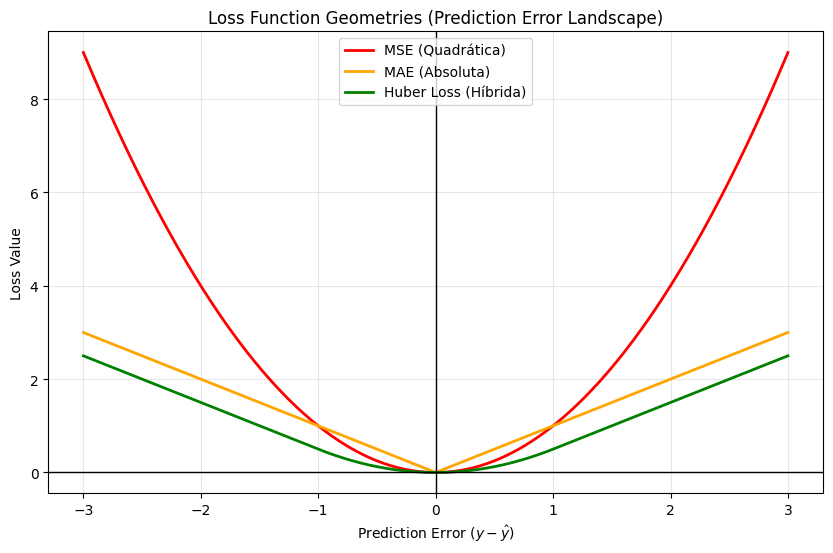

In [ ]:
# Instalação de dependências necessárias
%pip install torch numpy matplotlib scikit-learn

import torch
import numpy as np
import matplotlib.pyplot as plt

# Sementes fixas para reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)

def plot_loss_intuition():
    """Gera visualização das principais funções de loss para regressão."""
    errors = np.linspace(-3, 3, 500)

    # Cálculos das losses
    mse = errors**2
    mae = np.abs(errors)

    # Huber Loss (delta = 1)
    delta = 1.0
    huber = np.where(np.abs(errors) <= delta,
                     0.5 * errors**2,
                     delta * (np.abs(errors) - 0.5 * delta))

    plt.figure(figsize=(10, 6))
    plt.plot(errors, mse, label='MSE (Quadrática)', color='red', linewidth=2)
    plt.plot(errors, mae, label='MAE (Absoluta)', color='orange', linewidth=2)
    plt.plot(errors, huber, label='Huber Loss (Híbrida)', color='green', linewidth=2)

    plt.title('Loss Function Geometries (Prediction Error Landscape)')
    plt.xlabel('Prediction Error ($y - \hat{y}$)')
    plt.ylabel('Loss Value')
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_loss_intuition()

A seção a seguir detalha a formulação matemática e o rigor por trás de cada visualização.

## 3. Teoria Formal

### Regressão

**1. Mean Squared Error (MSE)**
O Erro Quadrático Médio é expresso pela média aritmética dos quadrados das diferenças entre os valores reais e as predições.
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
*Motivação:* Derivada diretamente da estatística de máxima verossimilhança assumindo erros gaussianos.
*Interpretação:* **Penaliza fortemente erros grandes e suaviza erros pequenos**.
*Limitação:* Altamente sensível a *outliers* (valores discrepantes que distorcem o aprendizado).
*Derivada (Regra da Cadeia):* Em relação à predição $\hat{y}_i$: $\frac{\partial MSE}{\partial \hat{y}_i} = \frac{2}{n}(\hat{y}_i - y_i)$.

**2. Mean Absolute Error (MAE)**
O Erro Absoluto Médio é a média dos módulos das diferenças.
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
*Motivação:* Ignorar o efeito catastrófico que os valores extremos aplicam na média.
*Interpretação:* Penaliza linearmente todos os erros de forma igualitária.
*Limitação:* A função **não é diferenciável em zero** (quando o erro é nulo), sendo necessário tratar a derivada com subgradientes na implementação computacional (ex: atribui-se zero no PyTorch).

**3. Huber Loss**
Combina MAE e MSE a partir de um limite limiar ($\delta$).
$$ L(y, \hat{y}) = \begin{cases} \frac{1}{2}(y - \hat{y})^2, & \text{se } |y - \hat{y}| \le \delta \\ \delta(|y - \hat{y}| - \frac{1}{2}\delta), & \text{se } |y - \hat{y}| > \delta \end{cases} $$
*Motivação:* Manter robustez a *outliers* do MAE enquanto preserva o contorno suave no ponto mínimo para evitar saltos desnecessários do gradiente.
*Interpretação:* Garante um cálculo contínuo, derivável em todos os pontos e suave.

### Classificação

**4. Cross-Entropy (Entropia Cruzada)**
Mede a distância entre duas distribuições de probabilidade. Para classificação binária:
$$L = - \frac{1}{n} \sum_{i=1}^{n} [y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)]$$
*Motivação:* Reduzir a divergência entre a distribuição real e a distribuição inferida pelo modelo.
*Interpretação:* **Quanto maior a certeza do modelo em uma previsão errada, massivamente maior será a penalização logarítmica**.
*Hipóteses:* Assume que $\hat{y}_i$ seja uma probabilidade ($0 \le \hat{y}_i \le 1$), frequentemente obtida após uma camada Sigmoid ou Softmax.

**5. Kullback-Leibler (KL) Divergence**
Mede a assimetria e a distância entre uma distribuição de probabilidade verdadeira $P(x)$ e uma aproximada $Q(x)$.
$$D_{KL}(P||Q) = \sum_{i} P(i) \log \frac{P(i)}{Q(i)}$$
*Motivação:* Utilizada como um termo de regularização para forçar a distribuição de ativações de uma rede neural a assemelhar-se à de outra.
*Interpretação:* Se a previsão e os dados reais coincidem ($P=Q$), a divergência resulta exatamente em zero (pois $\log(1)=0$). É vital para *Generative Adversarial Networks* (GANs) e *Self-Supervised Learning*.

Esta seção converte a fundação matemática em passos sistemáticos representados por pseudocódigos.

## 4. Algoritmos

O processo a seguir ilustra a lógica elementar da aplicação de *loss functions* durante uma etapa de aprendizado de máquina.

```text
ALGORITMO: Fluxo de Avaliação de Loss no Treinamento
ENTRADA: Previsões (Y_pred), Valores Reais (Y_real), Tipo de Problema
SAÍDA: Valor do Erro (Loss_Scalar), Gradiente do Erro (Loss_Gradient)

1. INICIAR Fluxo
2. SE Tipo de Problema for REGRESSÃO:
3.     SE existem muitos outliers:
4.         Loss_Scalar <- Calcular Huber Loss(Y_pred, Y_real, delta)
5.         Loss_Gradient <- Calcular Derivada_Huber(Y_pred, Y_real)
6.     SENÃO:
7.         Loss_Scalar <- Calcular MSE(Y_pred, Y_real)
8.         Loss_Gradient <- Calcular Derivada_MSE(Y_pred, Y_real)
9. FIM SE
10. SE Tipo de Problema for CLASSIFICAÇÃO:
11.    Y_prob <- Aplicar Softmax ou Sigmoid(Y_pred)
12.    Loss_Scalar <- Calcular CrossEntropy(Y_prob, Y_real)
13.    Loss_Gradient <- Calcular Derivada_CrossEntropy(Y_prob, Y_real)
14. FIM SE
15. RETORNAR Loss_Scalar, Loss_Gradient
```

*Explicação Passo a Passo:*
1. Recebe-se as predições do modelo e a verdade (*ground truth*).
2. O sistema avalia se é um caso de previsão contínua (regressão).
3-8. O tratamento de anomalias define se a abordagem usará o erro quadrático (MSE) ou uma alternativa suave e robusta (Huber). O cálculo de derivativas é imediatamente executado.
10-14. Para contextos categorizados, garante-se que os dados representam chances reais (via ativações de probabilidade). A Entropia Cruzada computa o escalar punitivo para previsões superconfiantes erradas e seu respectivo gradiente.

A seção subsequente transforma os algoritmos em código puro, construindo funções testáveis baseadas puramente na computação de matrizes.

## 5. Implementação from scratch

Nesta etapa, implementam-se as matemáticas puras discutidas usando NumPy.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, log_loss

class LossFunctionsScratch:
    """Implementações puras de funções de erro usando NumPy."""

    @staticmethod
    def mse(y_true, y_pred):
        """
        Calcula o Mean Squared Error (MSE).

        Args:
            y_true (np.array): Valores reais esperados.
            y_pred (np.array): Valores previstos pelo modelo.
        Returns:
            float: Erro escalar do MSE.
        """
        return np.mean((y_true - y_pred)**2)

    @staticmethod
    def binary_cross_entropy(y_true, y_pred):
        """
        Calcula a Entropia Cruzada Binária (Log Loss).
        Adiciona-se um epsilon (eps) para evitar instabilidade com log(0).
        """
        eps = 1e-15
        # Clipe para manter o logaritmo calculável, previnindo valores de 0 exatos.
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss

# --- Célula de Teste e Asserts ---
def test_loss_implementations():
    # Setup de dados sintéticos
    y_true_reg = np.array([3.0, -0.5, 2.0, 7.0])
    y_pred_reg = np.array([2.5, 0.0, 2.0, 8.0])

    y_true_cls = np.array([1, 0, 1, 1])
    y_pred_cls = np.array([0.9, 0.1, 0.8, 0.4])

    # Teste MSE
    scratch_mse = LossFunctionsScratch.mse(y_true_reg, y_pred_reg)
    sklearn_mse = mean_squared_error(y_true_reg, y_pred_reg)
    assert np.isclose(scratch_mse, sklearn_mse), 'Falha na equivalência MSE!'

    # Teste BCE
    scratch_bce = LossFunctionsScratch.binary_cross_entropy(y_true_cls, y_pred_cls)
    sklearn_bce = log_loss(y_true_cls, y_pred_cls)
    assert np.isclose(scratch_bce, sklearn_bce), 'Falha na equivalência BCE!'

    print('Testes passados com sucesso!')
    print(f'MSE Scratch: {scratch_mse:.4f} | Sklearn: {sklearn_mse:.4f}')
    print(f'BCE Scratch: {scratch_bce:.4f} | Sklearn: {sklearn_bce:.4f}')

test_loss_implementations()

Testes passados com sucesso!
MSE Scratch: 0.3750 | Sklearn: 0.3750
BCE Scratch: 0.3375 | Sklearn: 0.3375


A seguinte etapa aplica as abstrações computacionais usando APIs robustas de frameworks de altíssimo nível da indústria.

## 6. Implementação em PyTorch

O PyTorch moderniza o fluxo anterior. Os resultados devem ser os mesmos, mas acompanhados das facilidades de controle de tensores e abstração da propagação dos erros via AutoGrad.

In [ ]:
import torch
import torch.nn as nn

def pytorch_loss_equivalences():
    # Preparação de tensores. requires_grad=True simula uma predição em treinamento.
    y_true_reg = torch.tensor([3.0, -0.5, 2.0, 7.0])
    y_pred_reg = torch.tensor([2.5, 0.0, 2.0, 8.0], requires_grad=True)

    y_true_cls = torch.tensor([1.0, 0.0, 1.0, 1.0])
    y_pred_cls = torch.tensor([0.9, 0.1, 0.8, 0.4], requires_grad=True)

    # 1. API: nn.MSELoss()
    mse_criterion = nn.MSELoss()
    loss_mse = mse_criterion(y_pred_reg, y_true_reg)

    # 2. API: nn.BCELoss()
    bce_criterion = nn.BCELoss()
    loss_bce = bce_criterion(y_pred_cls, y_true_cls)

    print(f'PyTorch MSE Loss: {loss_mse.item():.4f}')
    print(f'PyTorch BCE Loss: {loss_bce.item():.4f}')

    # Validação do Backpropagation
    loss_mse.backward()
    print('\nGradientes gerados em y_pred_reg após backward() do MSE:')
    print(y_pred_reg.grad)

pytorch_loss_equivalences()

PyTorch MSE Loss: 0.3750
PyTorch BCE Loss: 0.3375

Gradientes gerados em y_pred_reg após backward() do MSE:
tensor([-0.2500,  0.2500,  0.0000,  0.5000])


Observe que APIs como o nn.MSELoss() automatizam não somente o *forward pass*, mas anexam funções matemáticas nativas ao grafo de computação, propiciando chamadas .backward() simples e seguras computacionalmente.

Esta seção consolida toda a teoria em um estudo empírico com hiperparâmetros, simulando adversidades do mundo real e gerando análise gráfica.

## 7. Experimentos e Análise

O experimento foca na limitação severa de sensibilidade a valores discrepantes do MSE e como a Huber Loss trata tal anomalia na prática do treinamento contínuo.

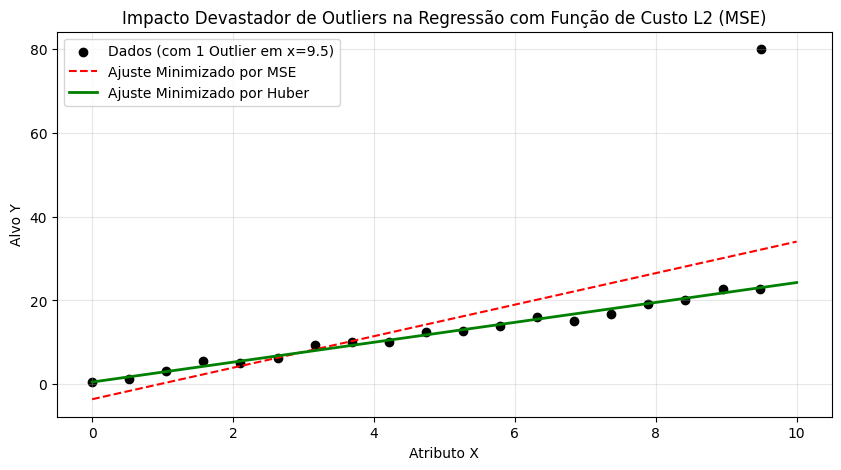

In [ ]:
from sklearn.linear_model import LinearRegression, HuberRegressor

def experiment_outlier_impact():
    """Roda experimento linear demonstrando a fraqueza do MSE frente ao Huber Loss na presença de anomalias."""

    # Dados de treinamento base
    X_train = np.linspace(0, 10, 20).reshape(-1, 1)
    y_train = 2.5 * X_train.ravel() + np.random.normal(0, 1, 20)

    # Inserção explícita de um Outlier Massivo no dataset
    X_train[-1] = 9.5
    y_train[-1] = 80.0  # Anomalia absurda inserida

    # Experimento A: Treinamento guiado minimizando o MSE
    mse_model = LinearRegression().fit(X_train, y_train)

    # Experimento B: Treinamento com robustez, usando métricas baseadas na Huber Loss
    huber_model = HuberRegressor(epsilon=1.35).fit(X_train, y_train)

    # Geração dos Espaços para Inferência
    X_test = np.linspace(0, 10, 50).reshape(-1, 1)
    y_pred_mse = mse_model.predict(X_test)
    y_pred_huber = huber_model.predict(X_test)

    # Plot e Análise
    plt.figure(figsize=(10, 5))
    plt.scatter(X_train, y_train, color='black', label='Dados (com 1 Outlier em x=9.5)')
    plt.plot(X_test, y_pred_mse, color='red', label='Ajuste Minimizado por MSE', linestyle='--')
    plt.plot(X_test, y_pred_huber, color='green', label='Ajuste Minimizado por Huber', linewidth=2)
    plt.title('Impacto Devastador de Outliers na Regressão com Função de Custo L2 (MSE)')
    plt.xlabel('Atributo X')
    plt.ylabel('Alvo Y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

experiment_outlier_impact()

### Análise Diagnóstica

A figura exposta elucida perfeitamente um erro crônico de diagnóstico de generalização: a superestimação impulsionada pelo MSE.

* **O problema prático diagnosticado:** Ao penalizar o grande outlier ao quadrado (algo como $50^2 = 2500$ de erro), o modelo usando MSE é forçado a distorcer brutalmente a inclinação linear da rede para acomodar o erro isolado.
* **Como diagnosticar no mundo real:** A disparidade brusca no erro de validação entre os folds de Cross Validation indicará alta variância em um subconjunto específico de dados.
* **Mitigação:** Optar por treinar a rede trocando a loss function pela Huber (definindo o hiperparâmetro $\delta$ em conjunto com a validação) suprime o problema; após um limite as punições viram lineares.

O segmento abaixo correlaciona o passado metodológico ao horizonte de engenharia do presente e futuro de ML.

## 8. Conexões com ML Moderno

Por que esse conceito continua moldando a revolução da Inteligência Artificial em 2024 e 2025?

A matemática das funções de *loss* encontra-se inalterada nos alicerces das arquiteturas soberanas:
1. **Transformers (LLMs):** Todo o treinamento generativo autorregressivo em modelos (como ChatGPT e LLaMA) resolve um problema massivo de predição multiclasse. A técnica utiliza a base da **Entropia Cruzada Multiclasse**. Um vocabulário com 100.000 tokens converte o treinamento em 100.000 classes possíveis por passo, computando os produtos do algoritmo Softmax integrados com as perdas logarítmicas.
2. **Difusão (Stable Diffusion, Midjourney):** As arquiteturas visionárias processam as imagens adicionando ruído estocástico, com a rede U-Net aprendendo um mapeamento inverso de retirada (denoising). O aprendizado consiste fundamentalmente em diminuir o ruído sintético versus o ruído previsto usando **Mean Squared Error (MSE)** como bússola de aprendizado.
3. **Regularização e Conhecimento:** A **Kullback-Leibler (KL) Divergence** é o pilar no Knowledge Distillation, onde um modelo filho emula a distribuição de predição latente gerada pela rede pai original, ou em RLHF (Reinforcement Learning from Human Feedback), penalizando agentes de reforço que desviam gravemente da distribuição natural imposta nos LLMs originais.

*Citação relevante do campo:*
> A KL Divergence mede a divergência de Q(X) que diverge da verdade de dados P(X); o domínio computacional moderno extrai disso regulações rigorosas vitais em Self-Supervised Learning.

Por fim, esta seção desafia e consolida o entendimento matemático do aprendiz através de bateria de exercícios.

## 9. Exercícios

### Resolvidos

**Exercício 1 (Matemática):** Dada a fórmula do Erro Quadrático Médio $MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2$, calcule matematicamente o gradiente descendente no que diz respeito ao parâmetro preditivo $\hat{y}_i$.
*Solução:*
Pela regra da cadeia, o foco atua na variável interna de derivação. Sendo $u = (y_i - \hat{y}_i)$ e a função externa $u^2$. A derivada de $u^2$ é $2u$. A derivada interna na função com respeito a $\hat{y}_i$ é $-1$. Multiplicando tudo: $2 * (y_i - \hat{y}_i) * -1$. Rearranjando: $2 (\hat{y}_i - y_i)$. Pela média de $n$: $\frac{2}{n}(\hat{y}_i - y_i)$.

**Exercício 2 (Conceitual):** Se uma rede neural alcança um valor de entropia cruzada de aproximadamente 4.6 quando a verdadeira predição era 1. Qual é a probabilidade que a rede havia alocado para essa classe antes da punição?
*Solução:*
No cálculo de classificação binária, o erro penaliza via $-\log(\hat{y}_{prob})$ quando $y_{verdade} = 1$. Para um erro valer 4.6, a probabilidade predita estaria na magnitude base de aproximadamente 0.01, demonstrando punições esmagadoras para excesso de confiança inversa.

**Exercício 3 (Modelagem):** Suponha a implementação de um classificador binário com Cross Entropy para distribuição de e-mails em categorias Spams. O modelo em treinamento exibe severa queda de confiabilidade nas medições por falta de confiança. Qual seria um método de regularização?
*Solução:*
Ao inserir Label Smoothing o valor alvo 1 se converte por exemplo para 0.9 visando não requerer 100% nas probabilidades previstas, freando tendências de sobreajuste severo das derivadas logarítmicas aos dados do treino e diminuindo a discrepância (Overfitting).

### Desafios Abertos

**Desafio 1 (Prático):** A função MAE em PyTorch não apresenta uma derivada válida no valor perfeito de erro 0 (ponto da função onde o V tem seu pico), e o motor resolve repassando zero. Implemente uma função customizável do MAE puro (forward) e substitua a implementação manual pelo pseudo subgradiente necessário durante a operação backward.
*Dica:* A derivada de uma função absoluta $f(x) = |x|$ equivale a 1 se $x > 0$, -1 se $x < 0$ e, sob o subgradiente heurístico do PyTorch, costuma retornar 0. Crie um objeto torch.autograd.Function.

**Desafio 2 (Teórico):** A divergência de Kullback-Leibler é matematicamente assimétrica, isto significa que $D_{KL}(P||Q) \ne D_{KL}(Q||P)$. Prove de maneira formal por que essa assimetria existe utilizando as propriedades fundamentais logarítmicas de esperança de funções.
*Dica:* Observe que a integral $\sum P(i) \log(P(i)/Q(i))$ exige que P paute a ponderação de importância da divisão probabilística em cada momento.